<a href="https://colab.research.google.com/github/argenviahouse-sys/aprendizajeautomatico1/blob/main/intro_reducci%C3%B3n_dimensionalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reducción de dimensionalidad paso a paso

¡Hola! Bienvenida a este cuaderno. Aquí aprenderás, paso a paso, cómo utilizar técnicas de reducción de dimensionalidad usando Python y la librería `scikit-learn`.

Aunque estamos enfocándonos en técnicas no supervisadas, es muy importante hacer una pequeña aclaración inicial: **PCA** y **t-SNE** son métodos no supervisados (no usan las etiquetas o respuestas de los datos para agruparlos), mientras que **LDA** es una técnica supervisada (sí usa las etiquetas para tratar de separar las clases). ¡Pero no te preocupes! Veremos las tres para que notes la gran diferencia de manera visual.

Para esto, vamos a utilizar el dataset **Wine** (Vino), que contiene 13 características químicas de diferentes tipos de vinos. Nuestro objetivo será reducir esas 13 dimensiones (que son imposibles de graficar para el ojo humano) a solo 2 dimensiones, para poder verlas en un gráfico plano.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Configuración de estilo básico para que los gráficos se vean más lindos
sns.set_theme(style='whitegrid')

# Cargamos el dataset de vinos
datos_vino = load_wine()
X = datos_vino.data
y = datos_vino.target
nombres_clases = datos_vino.target_names

# Es crucial escalar los datos antes de aplicar reducción de dimensionalidad
# Esto asegura que las variables con valores numéricos altos no dominen a las más pequeñas.
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print(f'Forma original de los datos: {X.shape} (tenemos 13 dimensiones)')

Forma original de los datos: (178, 13) (tenemos 13 dimensiones)


## 1. Análisis de componentes principales (PCA)

El PCA es la técnica no supervisada más básica, clásica y utilizada. Su meta es encontrar nuevas direcciones (a las que llamamos "componentes principales") que capturen la mayor cantidad de **varianza** (información o dispersión) posible de los datos originales.

Como es no supervisado, el algoritmo de PCA "no sabe" a qué clase pertenece cada tipo de vino; solo busca la mejor forma geométrica en la que los datos están distribuidos.

Forma de los datos después de PCA: (178, 2) (ahora son 2 dimensiones)


/tmp/ipykernel_6515/1864137031.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 3
  plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))
/tmp/ipykernel_6515/1864137031.py:17: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))


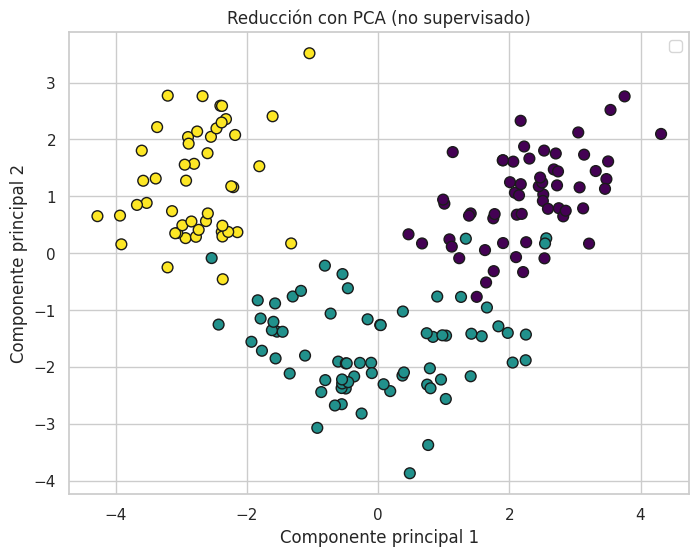

In [ ]:
from sklearn.decomposition import PCA

# Inicializamos PCA indicando que queremos reducir de 13 a 2 componentes
pca = PCA(n_components=2)

# Entrenamos y transformamos los datos (nota: solo usamos X, ignoramos la variable y)
X_pca = pca.fit_transform(X_escalado)

print(f'Forma de los datos después de PCA: {X_pca.shape} (ahora son 2 dimensiones)')

# Graficamos el resultado
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Reducción con PCA (no supervisado)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))
plt.show()

## 2. Análisis discriminante lineal (LDA)

A diferencia del PCA, el **LDA es un algoritmo supervisado**. Esto significa que toma en cuenta las etiquetas o clases (en nuestro código, la variable `y`).

Su objetivo no es solo mantener la mayor información posible, sino encontrar los ejes que **maximicen la separación matemática entre las diferentes clases**.

Verás en el gráfico de abajo que los clústeres (grupos de puntos del mismo color) se ven mucho más compactos y separados entre sí que en el PCA.

/tmp/ipykernel_6515/4039308731.py:15: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 3
  plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))
/tmp/ipykernel_6515/4039308731.py:15: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))


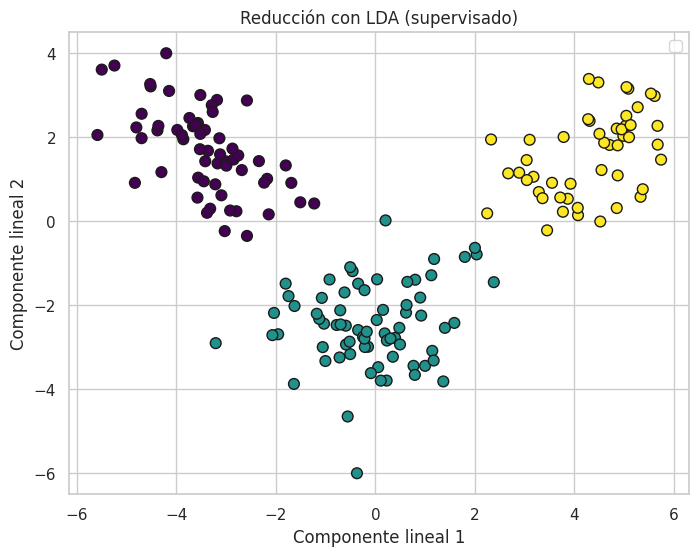

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Inicializamos LDA para 2 componentes
lda = LinearDiscriminantAnalysis(n_components=2)

# Entrenamos y transformamos (nota: aquí SÍ le pasamos 'y' porque el modelo lo necesita para aprender)
X_lda = lda.fit_transform(X_escalado, y)

# Graficamos el resultado
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Reducción con LDA (supervisado)')
plt.xlabel('Componente lineal 1')
plt.ylabel('Componente lineal 2')
plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))
plt.show()

## 3. t-SNE (t-distributed stochastic neighbor embedding)

Finalmente, vamos con otra técnica no supervisada, pero mucho más moderna: **t-SNE**. Mientras que PCA y LDA son métodos de transformación lineales, t-SNE es **no lineal**.

Esta técnica es excelente exclusivamente para visualización en 2D o 3D, ya que intenta mantener los puntos que son cercanos en las 13 dimensiones originales, también cerca en las 2 dimensiones del gráfico.

/tmp/ipykernel_6515/3086229681.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 3
  plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))
/tmp/ipykernel_6515/3086229681.py:16: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))


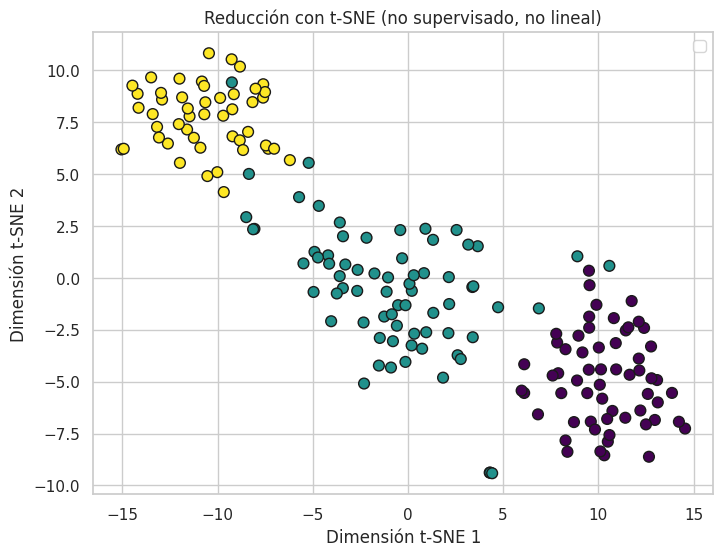

In [ ]:
from sklearn.manifold import TSNE

# Inicializamos t-SNE
# 'perplexity' es un parámetro que ajusta el balance entre la estructura local y global de los datos
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# Transformamos los datos (es no supervisado, así que no usamos 'y')
X_tsne = tsne.fit_transform(X_escalado)

# Graficamos el resultado final
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Reducción con t-SNE (no supervisado, no lineal)')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(handles=scatter.legend_elements(), labels=list(nombres_clases))
plt.show()

# UMAP

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad no lineal, similar a t-SNE, pero generalmente más rápida y escalable. Su objetivo es encontrar una representación de baja dimensión de los datos que preserve tanto la estructura local como la global. UMAP es una herramienta poderosa para la visualización de datos complejos y para la reducción de dimensionalidad antes de aplicar otros algoritmos de aprendizaje automático.


In [ ]:
# Instalar la librería UMAP-learn si aún no está instalada
!pip install umap-learn -qq

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Forma de los datos después de UMAP: (178, 2) (ahora son 2 dimensiones)


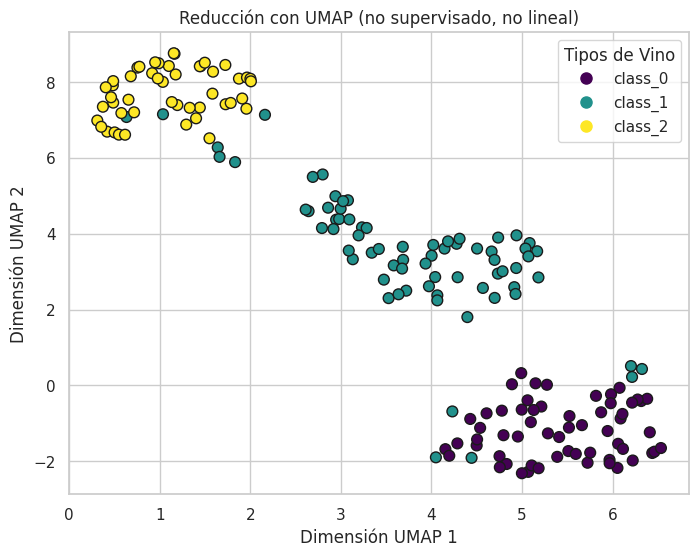

In [ ]:
import umap
import numpy as np

# Inicializamos UMAP
# n_neighbors y min_dist son parámetros clave para UMAP, ajustando el balance entre estructura local y global.
umap_reductor = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Transformamos los datos (es no supervisado, así que no usamos 'y')
X_umap = umap_reductor.fit_transform(X_escalado)

print(f'Forma de los datos después de UMAP: {X_umap.shape} (ahora son 2 dimensiones)')

# Graficamos el resultado final
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Reducción con UMAP (no supervisado, no lineal)')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')

# Crear elementos proxy para la leyenda de forma manual para evitar el UserWarning
proxy_handles = []
cmap = scatter.cmap
norm = scatter.norm
unique_classes = sorted(np.unique(y)) # Asegurar el orden de las clases

for class_val, class_name in zip(unique_classes, nombres_clases):
    proxy_handles.append(plt.Line2D([0], [0],
                                    marker='o',
                                    linestyle='',
                                    color=cmap(norm(class_val)), # Obtener color del colormap
                                    label=class_name,
                                    markersize=8))

plt.legend(handles=proxy_handles, title="Tipos de Vino")
plt.show()

## Conclusión

¡Excelente trabajo! Como pudiste observar en los gráficos, cada técnica te será útil para distintos propósitos:

* **PCA**: Es tu técnica ideal de partida. Es rápida, no supervisada y excelente para reducir ruido manteniendo la estructura global de tus datos.
* **LDA**: Es tu opción número uno si ya conoces las etiquetas de tus datos (supervisado) y quieres proyectarlos de forma que las clases queden lo más separadas posible antes de dárselos a un modelo de clasificación.
* **t-SNE y UMAP**: herramientas estrella si el objetivo principal es puramente visualización de clústeres y relaciones complejas.

¡Espero que te sientas lista para aplicar todo esto y que este material te sea de gran utilidad en tus propios proyectos de ciencia de datos!